In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch_geometric.datasets import Planetoid


In [2]:
dataset = Planetoid(root="data/Planetoid/Cora", name="Cora")
data = dataset[0]

print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.num_edges)
print("Number of node features:", dataset.num_features)
print("Number of classes:", dataset.num_classes)


Number of nodes: 2708
Number of edges: 10556
Number of node features: 1433
Number of classes: 7


Processing...
Done!


In [3]:
labels = data.y.cpu().numpy()

unique, counts = np.unique(labels, return_counts=True)
class_counts = dict(zip(unique, counts))

class_counts


{np.int64(0): np.int64(351),
 np.int64(1): np.int64(217),
 np.int64(2): np.int64(418),
 np.int64(3): np.int64(818),
 np.int64(4): np.int64(426),
 np.int64(5): np.int64(298),
 np.int64(6): np.int64(180)}

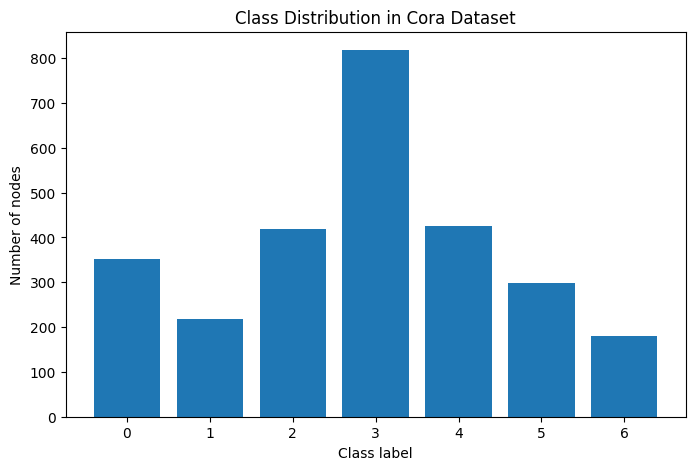

In [4]:
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class label")
plt.ylabel("Number of nodes")
plt.title("Class Distribution in Cora Dataset")
plt.show()


In [5]:
edge_index = data.edge_index

# Count degree per node
degrees = torch.bincount(edge_index[0], minlength=data.num_nodes).cpu().numpy()


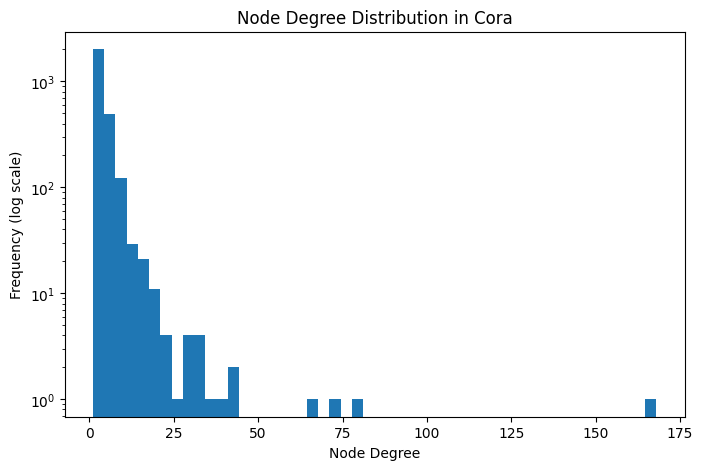

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=50, log=True)
plt.xlabel("Node Degree")
plt.ylabel("Frequency (log scale)")
plt.title("Node Degree Distribution in Cora")
plt.show()


In [7]:
num_nodes = data.num_nodes
num_edges = data.num_edges

possible_edges = num_nodes * (num_nodes - 1)
density = num_edges / possible_edges

print(f"Graph density: {density:.6f}")


Graph density: 0.001440


In [8]:
print("Train nodes:", int(data.train_mask.sum()))
print("Validation nodes:", int(data.val_mask.sum()))
print("Test nodes:", int(data.test_mask.sum()))


Train nodes: 140
Validation nodes: 500
Test nodes: 1000
